# Лабараторная работа 2. RNN

### Классификация эмоций в твитах (sadness, joy, love, anger, fear, surprise)

In [1]:
import os
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report
from tqdm.auto import tqdm
import re
import copy

c:\Users\Андрей\ML\NeuralNetworksLabs\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("CUDA available:", torch.cuda.is_available())
if device.type == "cuda":
    print("GPU name:", torch.cuda.get_device_name(0))

Using device: cuda
CUDA available: True
GPU name: NVIDIA GeForce RTX 2060


## Задание 1: Подготовка данных

Датасет **Tweet Emotions** содержит твиты, размеченные по 6 категориям эмоций:
- 0 — sadness (грусть)
- 1 — joy (радость)
- 2 — love (любовь)
- 3 — anger (злость)
- 4 — fear (страх)
- 5 — surprise (удивление)

### Предобработка:
1. Очистка текста (удаление URL, спецсимволов, приведение к нижнему регистру)
2. Токенизация на уровне слов
3. Построение словаря и преобразование текстов в числовые последовательности
4. Дополнение/обрезка последовательностей до фиксированной длины (padding)
5. Аугментация данных для обучающей выборки (random token dropout)

In [3]:
DATA_DIR = "data"
MAX_SEQ_LEN = 64
BATCH_SIZE = 64
VOCAB_MIN_FREQ = 2

CLASS_NAMES = ["sadness", "joy", "love", "anger", "fear", "surprise"]
NUM_CLASSES = len(CLASS_NAMES)

In [5]:
# Загрузка данных
train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
val_df   = pd.read_csv(os.path.join(DATA_DIR, "val.csv"))
test_df  = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

# Приведение типов
train_df["label"] = train_df["label"].astype(int)
val_df["label"]   = val_df["label"].astype(int)
test_df["label"]  = test_df["label"].astype(int)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print("\nПримеры данных:")
train_df.head()

Train: 16000 | Val: 2000 | Test: 2000

Примеры данных:


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


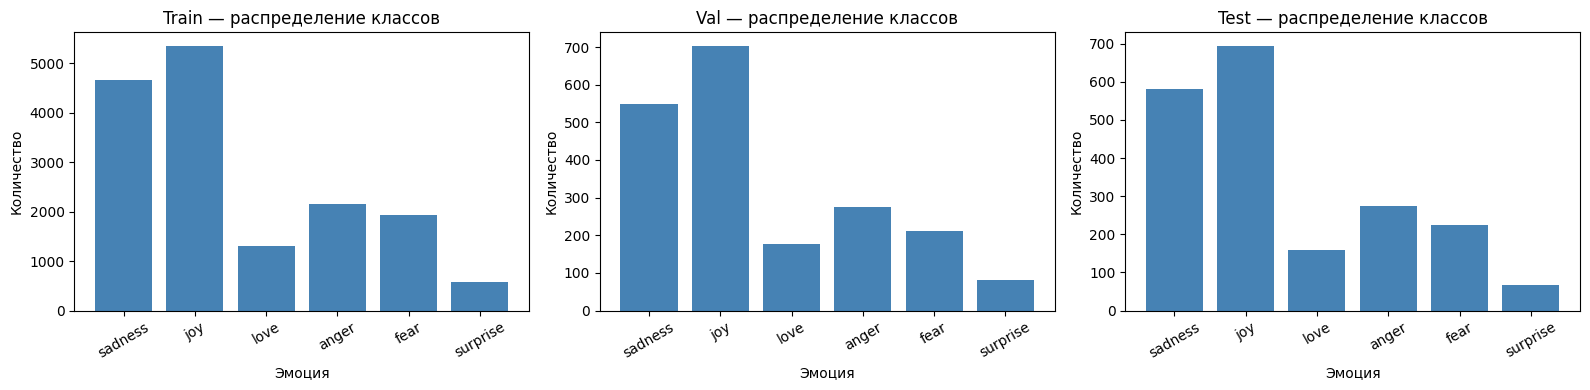

In [6]:
# Распределение классов
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (df, name) in zip(axes, [(train_df, "Train"), (val_df, "Val"), (test_df, "Test")]):
    counts = df["label"].value_counts().sort_index()
    ax.bar([CLASS_NAMES[i] for i in counts.index], counts.values, color="steelblue")
    ax.set_title(f"{name} — распределение классов")
    ax.set_xlabel("Эмоция")
    ax.set_ylabel("Количество")
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

In [7]:
# Очистка текста
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)   # удалить URL
    text = re.sub(r"@\w+", "", text)              # удалить упоминания @user
    text = re.sub(r"#\w+", "", text)              # удалить хэштеги
    text = re.sub(r"[^a-z\s']", "", text)         # оставить только буквы
    text = re.sub(r"\s+", " ", text).strip()       # нормализовать пробелы
    return text

for df in [train_df, val_df, test_df]:
    df["text"] = df["text"].apply(clean_text)

print("Примеры после очистки:")
train_df[["text", "label"]].head()

Примеры после очистки:


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [8]:
# Построение словаря
PAD_TOKEN = "<PAD>"   # индекс 0 — паддинг
UNK_TOKEN = "<UNK>"   # индекс 1 — неизвестное слово

word_counts = Counter()
for text in train_df["text"]:
    word_counts.update(text.split())

vocab = [PAD_TOKEN, UNK_TOKEN] + [
    w for w, c in word_counts.most_common() if c >= VOCAB_MIN_FREQ
]
word2idx = {w: i for i, w in enumerate(vocab)}
VOCAB_SIZE = len(vocab)

print(f"Размер словаря: {VOCAB_SIZE}")
print(f"Топ-20 слов: {list(word2idx.keys())[2:22]}")

Размер словаря: 7400
Топ-20 слов: ['i', 'feel', 'and', 'to', 'the', 'a', 'feeling', 'that', 'of', 'my', 'in', 'it', 'like', 'so', 'for', 'im', 'me', 'but', 'was', 'have']


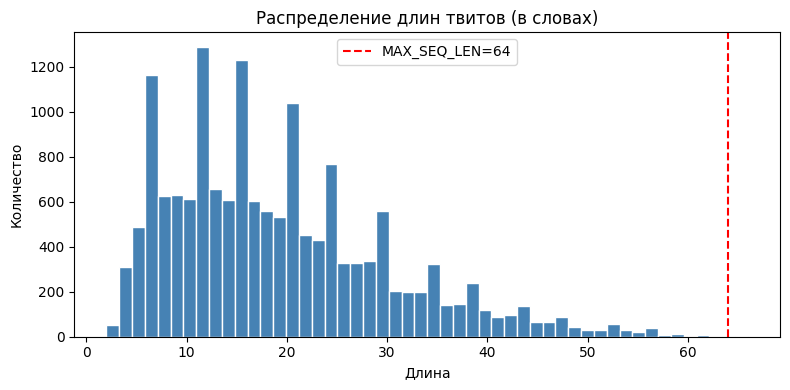

Медиана: 17 | 95-й перцентиль: 41 | Макс: 66


In [9]:
# Функции кодирования и анализа длин
def encode(text, word2idx, max_len):
    tokens = text.split()[:max_len]
    ids = [word2idx.get(t, 1) for t in tokens]  # 1 = UNK
    # padding справа
    ids += [0] * (max_len - len(ids))
    return ids

lengths = [len(t.split()) for t in train_df["text"]]
plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=50, color="steelblue", edgecolor="white")
plt.axvline(MAX_SEQ_LEN, color="red", linestyle="--", label=f"MAX_SEQ_LEN={MAX_SEQ_LEN}")
plt.title("Распределение длин твитов (в словах)")
plt.xlabel("Длина")
plt.ylabel("Количество")
plt.legend()
plt.tight_layout()
plt.show()
print(f"Медиана: {np.median(lengths):.0f} | 95-й перцентиль: {np.percentile(lengths, 95):.0f} | Макс: {max(lengths)}")

In [10]:
# Dataset с аугментацией для обучения
class TweetDataset(Dataset):
    """
    Аугментация (только для train):
    - Random token dropout: каждый токен с вероятностью p_drop заменяется на <UNK>
    - Random swap: с вероятностью p_swap меняем два соседних токена местами
    """
    def __init__(self, df, word2idx, max_len, augment=False, p_drop=0.1, p_swap=0.1):
        self.texts  = df["text"].tolist()
        self.labels = df["label"].tolist()
        self.word2idx = word2idx
        self.max_len  = max_len
        self.augment  = augment
        self.p_drop   = p_drop
        self.p_swap   = p_swap

    def __len__(self):
        return len(self.texts)

    def _augment(self, tokens):
        # Random token dropout → UNK
        tokens = [t if np.random.random() > self.p_drop else 1 for t in tokens]
        # Random adjacent swap
        for i in range(len(tokens) - 1):
            if np.random.random() < self.p_swap:
                tokens[i], tokens[i+1] = tokens[i+1], tokens[i]
        return tokens

    def __getitem__(self, idx):
        ids = encode(self.texts[idx], self.word2idx, self.max_len)
        if self.augment:
            # применяем только к непаддинговым токенам
            real_len = sum(1 for x in ids if x != 0)
            ids[:real_len] = self._augment(ids[:real_len])
        x = torch.tensor(ids, dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y


train_dataset = TweetDataset(train_df, word2idx, MAX_SEQ_LEN, augment=True)
val_dataset   = TweetDataset(val_df,   word2idx, MAX_SEQ_LEN, augment=False)
test_dataset  = TweetDataset(test_df,  word2idx, MAX_SEQ_LEN, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 16000 | Val: 2000 | Test: 2000


In [11]:
# Веса классов для борьбы с дисбалансом
label_counts = Counter(train_df["label"].tolist())
n_total = len(train_df)
class_weights = torch.tensor(
    [n_total / (NUM_CLASSES * label_counts[i]) for i in range(NUM_CLASSES)],
    dtype=torch.float
).to(device)
print("Веса классов:", {CLASS_NAMES[i]: f"{class_weights[i].item():.3f}" for i in range(NUM_CLASSES)})

Веса классов: {'sadness': '0.572', 'joy': '0.497', 'love': '2.045', 'anger': '1.235', 'fear': '1.377', 'surprise': '4.662'}


## Задание 2: Архитектуры RNN

Разработаны **3 собственные архитектуры** + **3 классические** (RNN, LSTM, GRU).

### Общая схема:
```
Input (токены) → Embedding → Рекуррентные слои → Агрегация → Classifier → Softmax
```

### Обучающая функция

In [12]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

def train_model(model, train_loader, val_loader, num_epochs=30, patience=5, lr=1e-3):
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    patience_counter = 0

    for epoch in range(num_epochs):
        for phase in ["train", "val"]:
            model.train() if phase == "train" else model.eval()
            loader = train_loader if phase == "train" else val_loader

            running_loss = 0.0
            running_correct = 0

            loop = tqdm(loader, desc=f"Epoch {epoch+1}/{num_epochs} [{phase}]", leave=False)
            for x, y in loop:
                x, y = x.to(device), y.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(x)
                    loss = criterion(outputs, y)
                    if phase == "train":
                        loss.backward()
                        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                        optimizer.step()

                preds = outputs.argmax(dim=1)
                running_loss    += loss.item() * x.size(0)
                running_correct += (preds == y).sum().item()
                loop.set_postfix(loss=f"{loss.item():.4f}")

            epoch_loss = running_loss / len(loader.dataset)
            epoch_acc  = running_correct / len(loader.dataset)
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)

            if phase == "val":
                scheduler.step(epoch_acc)
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_wts = copy.deepcopy(model.state_dict())
                    patience_counter = 0
                else:
                    patience_counter += 1

        print(f"Epoch {epoch+1:02d}/{num_epochs} | "
              f"Train Loss: {history['train_loss'][-1]:.4f} Acc: {history['train_acc'][-1]:.4f} | "
              f"Val Loss: {history['val_loss'][-1]:.4f} Acc: {history['val_acc'][-1]:.4f}")

        if patience_counter >= patience:
            print(f"Early stopping на эпохе {epoch+1}. Лучший Val Acc: {best_acc:.4f}")
            break

    model.load_state_dict(best_wts)
    print(f"\nЛучший Val Accuracy: {best_acc:.4f}")
    return model, history

---
## Классические архитектуры

### Архитектура A: Vanilla RNN
Простая дву-направленная рекуррентная сеть. Использует `nn.RNN` — базовый рекуррентный слой без механизмов памяти. Подвержена проблеме затухающих градиентов на длинных последовательностях.

In [40]:
class VanillaRNN(nn.Module):
    """
    Embedding → Bi-RNN (2 слоя) → Max Pool по времени → BN → Linear
    Активация: tanh (встроена в nn.RNN)
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=dropout,
            nonlinearity='tanh'
        )
        self.bn = nn.BatchNorm1d(hidden_dim * 2)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        emb = self.dropout(self.embedding(x))       # (B, L, E)
        out, _ = self.rnn(emb)                      # (B, L, 2H)
        # Max Pool по временному измерению
        pooled = out.max(dim=1).values              # (B, 2H)
        pooled = self.bn(pooled)
        return self.fc(self.dropout(pooled))


model_rnn = VanillaRNN(
    vocab_size=VOCAB_SIZE, embed_dim=128, hidden_dim=256,
    num_classes=NUM_CLASSES, dropout=0.4
).to(device)

print(model_rnn)
total_params = sum(p.numel() for p in model_rnn.parameters())
print(f"Параметров: {total_params:,}")


VanillaRNN(
  (embedding): Embedding(7400, 128, padding_idx=0)
  (rnn): RNN(128, 256, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (bn): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=256, out_features=6, bias=True)
  )
)
Параметров: 1,672,966


In [34]:
model_rnn, history_rnn = train_model(
    model_rnn, train_loader, val_loader,
    num_epochs=100, patience=10, lr=3e-4
)


Epoch 01/100 | Train Loss: 1.8253 Acc: 0.1854 | Val Loss: 1.7921 Acc: 0.1760


Epoch 02/100 | Train Loss: 1.7888 Acc: 0.1978 | Val Loss: 1.7104 Acc: 0.2205


Epoch 03/100 | Train Loss: 1.7479 Acc: 0.1999 | Val Loss: 1.6315 Acc: 0.2470


Epoch 04/100 | Train Loss: 1.7081 Acc: 0.2280 | Val Loss: 1.5411 Acc: 0.3085


Epoch 05/100 | Train Loss: 1.6379 Acc: 0.2474 | Val Loss: 1.4860 Acc: 0.4010


...

Epoch 80/100 | Train Loss: 0.3697 Acc: 0.8622 | Val Loss: 0.1320 Acc: 0.9345


Epoch 81/100 | Train Loss: 0.3477 Acc: 0.8631 | Val Loss: 0.1347 Acc: 0.9355


Epoch 82/100 | Train Loss: 0.3475 Acc: 0.8604 | Val Loss: 0.1332 Acc: 0.9345


Epoch 83/100 | Train Loss: 0.3464 Acc: 0.8624 | Val Loss: 0.1319 Acc: 0.9345


Epoch 84/100 | Train Loss: 0.3493 Acc: 0.8599 | Val Loss: 0.1326 Acc: 0.9340
Early stopping на эпохе 84. Лучший Val Acc: 0.9360

Лучший Val Accuracy: 0.9360


---
### Архитектура B: LSTM
Long Short-Term Memory — классическое решение проблемы затухающих градиентов. Ячейка памяти `c_t` и три гейта (input, forget, output) позволяют сети запоминать долгосрочные зависимости. Двунаправленная версия обрабатывает текст в обоих направлениях.

In [16]:
class LSTMClassifier(nn.Module):
    """
    Embedding → Bi-LSTM (2 слоя) → конкатенация последних состояний → Dropout → Linear
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        # bidirectional → hidden_dim * 2
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))        # (B, L, E)
        out, (h, _) = self.lstm(emb)                 # h: (num_layers*2, B, H)
        # берём последний слой (forward + backward)
        h_fwd = h[-2]  # (B, H)
        h_bwd = h[-1]  # (B, H)
        h_cat = torch.cat([h_fwd, h_bwd], dim=1)    # (B, 2H)
        return self.fc(self.dropout(h_cat))


model_lstm = LSTMClassifier(
    vocab_size=VOCAB_SIZE, embed_dim=128, hidden_dim=256,
    num_classes=NUM_CLASSES, num_layers=2, dropout=0.3
).to(device)

print(model_lstm)
total_params = sum(p.numel() for p in model_lstm.parameters())
print(f"Параметров: {total_params:,}")

LSTMClassifier(
  (embedding): Embedding(7400, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=512, out_features=6, bias=True)
)
Параметров: 3,317,766


In [19]:
model_lstm, history_lstm = train_model(model_lstm, train_loader, val_loader, num_epochs=100, patience=10)

Epoch 01/100 | Train Loss: 0.4564 Acc: 0.8357 | Val Loss: 0.2034 Acc: 0.9165


Epoch 02/100 | Train Loss: 0.4042 Acc: 0.8468 | Val Loss: 0.1738 Acc: 0.9210


Epoch 03/100 | Train Loss: 0.3769 Acc: 0.8557 | Val Loss: 0.1690 Acc: 0.9215


Epoch 04/100 | Train Loss: 0.3706 Acc: 0.8574 | Val Loss: 0.1648 Acc: 0.9260


Epoch 05/100 | Train Loss: 0.3621 Acc: 0.8643 | Val Loss: 0.1553 Acc: 0.9310


...

Epoch 19/100 | Train Loss: 0.2471 Acc: 0.9009 | Val Loss: 0.1861 Acc: 0.9390


Epoch 20/100 | Train Loss: 0.2394 Acc: 0.9068 | Val Loss: 0.1865 Acc: 0.9400


Epoch 21/100 | Train Loss: 0.2439 Acc: 0.9057 | Val Loss: 0.1830 Acc: 0.9375


Epoch 22/100 | Train Loss: 0.2277 Acc: 0.9064 | Val Loss: 0.1908 Acc: 0.9395


Epoch 23/100 | Train Loss: 0.2322 Acc: 0.9078 | Val Loss: 0.1892 Acc: 0.9410
Early stopping на эпохе 23. Лучший Val Acc: 0.9420

Лучший Val Accuracy: 0.9420


---
### Архитектура C: GRU
Gated Recurrent Unit — упрощённая версия LSTM: два гейта (reset, update) вместо трёх, нет отдельной ячейки памяти. Обычно быстрее LSTM при сопоставимом качестве.

In [20]:
class GRUClassifier(nn.Module):
    """
    Embedding → Bi-GRU (2 слоя) → конкатенация последних состояний → Dropout → Linear
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))     # (B, L, E)
        _, h = self.gru(emb)                       # h: (num_layers*2, B, H)
        h_fwd = h[-2]
        h_bwd = h[-1]
        h_cat = torch.cat([h_fwd, h_bwd], dim=1)  # (B, 2H)
        return self.fc(self.dropout(h_cat))


model_gru = GRUClassifier(
    vocab_size=VOCAB_SIZE, embed_dim=128, hidden_dim=256,
    num_classes=NUM_CLASSES, num_layers=2, dropout=0.3
).to(device)

print(model_gru)
total_params = sum(p.numel() for p in model_gru.parameters())
print(f"Параметров: {total_params:,}")

GRUClassifier(
  (embedding): Embedding(7400, 128, padding_idx=0)
  (gru): GRU(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=512, out_features=6, bias=True)
)
Параметров: 2,725,894


In [21]:
model_gru, history_gru = train_model(model_gru, train_loader, val_loader, num_epochs=100, patience=10)

Epoch 01/100 | Train Loss: 1.7645 Acc: 0.2036 | Val Loss: 1.6085 Acc: 0.2480


Epoch 02/100 | Train Loss: 1.3481 Acc: 0.3942 | Val Loss: 0.7108 Acc: 0.6875


Epoch 03/100 | Train Loss: 0.8895 Acc: 0.6402 | Val Loss: 0.4372 Acc: 0.7940


Epoch 04/100 | Train Loss: 0.6889 Acc: 0.7428 | Val Loss: 0.2925 Acc: 0.8745


Epoch 05/100 | Train Loss: 0.5245 Acc: 0.8067 | Val Loss: 0.2202 Acc: 0.9045


...

Epoch 25/100 | Train Loss: 0.2507 Acc: 0.9052 | Val Loss: 0.1665 Acc: 0.9395


Epoch 26/100 | Train Loss: 0.2423 Acc: 0.9035 | Val Loss: 0.1688 Acc: 0.9380


Epoch 27/100 | Train Loss: 0.2291 Acc: 0.9094 | Val Loss: 0.1750 Acc: 0.9385


Epoch 28/100 | Train Loss: 0.2344 Acc: 0.9109 | Val Loss: 0.1708 Acc: 0.9385


Epoch 29/100 | Train Loss: 0.2228 Acc: 0.9137 | Val Loss: 0.1721 Acc: 0.9385
Early stopping на эпохе 29. Лучший Val Acc: 0.9435

Лучший Val Accuracy: 0.9435


---
## Собственные архитектуры

### Архитектура 1: LSTM + Attention
Механизм внимания (Attention) позволяет модели самостоятельно определять, какие токены последовательности наиболее важны для классификации. Вместо того чтобы использовать только последнее скрытое состояние, вычисляется взвешенная сумма всех выходов LSTM.

In [22]:
class AttentionLSTM(nn.Module):
    """
    Embedding → Bi-LSTM → Attention (Bahdanau-style) → взвешенная сумма → Dropout → Linear
    Функции активации: tanh (в LSTM), softmax (attention weights)
    Регуляризация: Dropout на embedding и перед классификатором
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers=2,
            batch_first=True, bidirectional=True, dropout=dropout
        )
        # Attention: проекция скрытых состояний → скалярный скор
        self.attention = nn.Linear(hidden_dim * 2, 1)
        self.dropout   = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        emb = self.dropout(self.embedding(x))         # (B, L, E)
        out, _ = self.lstm(emb)                        # (B, L, 2H)

        # Attention scores
        scores = self.attention(out).squeeze(-1)       # (B, L)
        # Маскирование паддинга
        mask = (x == 0)
        scores = scores.masked_fill(mask, float('-inf'))
        weights = torch.softmax(scores, dim=1)         # (B, L)

        # Взвешенная сумма
        context = torch.bmm(weights.unsqueeze(1), out).squeeze(1)  # (B, 2H)
        return self.fc(self.dropout(context))


model_v1 = AttentionLSTM(
    vocab_size=VOCAB_SIZE, embed_dim=128, hidden_dim=256,
    num_classes=NUM_CLASSES, dropout=0.4
).to(device)

print(model_v1)
print(f"Параметров: {sum(p.numel() for p in model_v1.parameters()):,}")

AttentionLSTM(
  (embedding): Embedding(7400, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (attention): Linear(in_features=512, out_features=1, bias=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=256, out_features=6, bias=True)
  )
)
Параметров: 3,448,071


In [23]:
model_v1, history_v1 = train_model(model_v1, train_loader, val_loader, num_epochs=100, patience=10)

Epoch 01/100 | Train Loss: 1.7237 Acc: 0.2234 | Val Loss: 1.2745 Acc: 0.4325


Epoch 02/100 | Train Loss: 1.2473 Acc: 0.4274 | Val Loss: 0.6298 Acc: 0.6955


Epoch 03/100 | Train Loss: 0.8476 Acc: 0.6448 | Val Loss: 0.3825 Acc: 0.8435


Epoch 04/100 | Train Loss: 0.6793 Acc: 0.7403 | Val Loss: 0.3031 Acc: 0.8780


Epoch 05/100 | Train Loss: 0.5600 Acc: 0.7913 | Val Loss: 0.2305 Acc: 0.9000


...

Epoch 23/100 | Train Loss: 0.2747 Acc: 0.8886 | Val Loss: 0.1561 Acc: 0.9380


Epoch 24/100 | Train Loss: 0.2751 Acc: 0.8877 | Val Loss: 0.1565 Acc: 0.9380


Epoch 25/100 | Train Loss: 0.2740 Acc: 0.8904 | Val Loss: 0.1608 Acc: 0.9370


Epoch 26/100 | Train Loss: 0.2717 Acc: 0.8878 | Val Loss: 0.1686 Acc: 0.9395


Epoch 27/100 | Train Loss: 0.2598 Acc: 0.8904 | Val Loss: 0.1764 Acc: 0.9405
Early stopping на эпохе 27. Лучший Val Acc: 0.9405

Лучший Val Accuracy: 0.9405


---
### Архитектура 2: Stacked GRU + Global Max Pooling
Глубокая GRU-сеть с тремя слоями разной ширины. Вместо последнего состояния используется **Global Max Pooling** по всей последовательности — выбираем наиболее «возбуждённые» признаки, что помогает выделить ключевые эмоциональные маркеры независимо от их позиции в тексте.

In [24]:
class StackedGRUMaxPool(nn.Module):
    """
    Embedding → 3x Bi-GRU с разной размерностью → Global Max Pooling → BN → Linear
    Функции активации: сигмоид/tanh (внутри GRU), ReLU (классификатор)
    Регуляризация: Dropout между слоями + BatchNorm перед классификатором
    """
    def __init__(self, vocab_size, embed_dim, num_classes, dropout=0.35):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout   = nn.Dropout(dropout)

        self.gru1 = nn.GRU(embed_dim, 256, batch_first=True, bidirectional=True)
        self.gru2 = nn.GRU(512,       128, batch_first=True, bidirectional=True)
        self.gru3 = nn.GRU(256,        64, batch_first=True, bidirectional=True)

        self.bn = nn.BatchNorm1d(128)  # 64 * 2 = 128
        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        emb = self.dropout(self.embedding(x))    # (B, L, E)
        o1, _ = self.gru1(emb)                   # (B, L, 512)
        o2, _ = self.gru2(self.dropout(o1))      # (B, L, 256)
        o3, _ = self.gru3(self.dropout(o2))      # (B, L, 128)
        # Global Max Pooling
        pooled = o3.max(dim=1).values            # (B, 128)
        pooled = self.bn(pooled)
        return self.fc(pooled)


model_v2 = StackedGRUMaxPool(
    vocab_size=VOCAB_SIZE, embed_dim=128,
    num_classes=NUM_CLASSES, dropout=0.35
).to(device)

print(model_v2)
print(f"Параметров: {sum(p.numel() for p in model_v2.parameters()):,}")

StackedGRUMaxPool(
  (embedding): Embedding(7400, 128, padding_idx=0)
  (dropout): Dropout(p=0.35, inplace=False)
  (gru1): GRU(128, 256, batch_first=True, bidirectional=True)
  (gru2): GRU(512, 128, batch_first=True, bidirectional=True)
  (gru3): GRU(256, 64, batch_first=True, bidirectional=True)
  (bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.35, inplace=False)
    (3): Linear(in_features=64, out_features=6, bias=True)
  )
)
Параметров: 2,165,702


In [25]:
model_v2, history_v2 = train_model(model_v2, train_loader, val_loader, num_epochs=100, patience=10)

Epoch 01/100 | Train Loss: 1.7690 Acc: 0.1897 | Val Loss: 1.6653 Acc: 0.3080


Epoch 02/100 | Train Loss: 1.5326 Acc: 0.2838 | Val Loss: 1.0676 Acc: 0.4685


Epoch 03/100 | Train Loss: 1.1466 Acc: 0.4755 | Val Loss: 0.5483 Acc: 0.7440


Epoch 04/100 | Train Loss: 0.8543 Acc: 0.6441 | Val Loss: 0.3929 Acc: 0.8540


Epoch 05/100 | Train Loss: 0.6825 Acc: 0.7476 | Val Loss: 0.2890 Acc: 0.8850


...

Epoch 24/100 | Train Loss: 0.3014 Acc: 0.8810 | Val Loss: 0.1769 Acc: 0.9395


Epoch 25/100 | Train Loss: 0.2779 Acc: 0.8872 | Val Loss: 0.1858 Acc: 0.9375


Epoch 26/100 | Train Loss: 0.2818 Acc: 0.8891 | Val Loss: 0.1938 Acc: 0.9370


Epoch 27/100 | Train Loss: 0.2885 Acc: 0.8882 | Val Loss: 0.2066 Acc: 0.9345


Epoch 28/100 | Train Loss: 0.2939 Acc: 0.8898 | Val Loss: 0.1997 Acc: 0.9370
Early stopping на эпохе 28. Лучший Val Acc: 0.9395

Лучший Val Accuracy: 0.9395


---
### Архитектура 3: GRU + LSTM гибридная сеть
Гибридная архитектура: GRU обрабатывает последовательность первым (быстрый захват локальных паттернов), затем LSTM дополнительно извлекает долгосрочные зависимости. Выходы объединяются через **конкатенацию** (max-pool + mean-pool) для получения более богатого представления.

In [26]:
class HybridGRULSTM(nn.Module):
    """
    Embedding → Bi-GRU → Bi-LSTM → (Max Pool + Avg Pool) конкатенация → Linear
    Функции активации: сигмоид/tanh (внутри GRU/LSTM), ELU (классификатор)
    Регуляризация: Dropout + LayerNorm после агрегации
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout   = nn.Dropout(dropout)

        self.gru = nn.GRU(
            embed_dim, hidden_dim, num_layers=1,
            batch_first=True, bidirectional=True
        )
        self.lstm = nn.LSTM(
            hidden_dim * 2, hidden_dim, num_layers=1,
            batch_first=True, bidirectional=True
        )
        lstm_out = hidden_dim * 2
        self.norm = nn.LayerNorm(lstm_out * 2)   # max + avg
        self.fc = nn.Sequential(
            nn.Linear(lstm_out * 2, lstm_out),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(lstm_out, num_classes)
        )

    def forward(self, x):
        emb = self.dropout(self.embedding(x))       # (B, L, E)
        gru_out, _ = self.gru(emb)                  # (B, L, 2H)
        lstm_out, _ = self.lstm(self.dropout(gru_out))  # (B, L, 2H)

        # Двойная агрегация
        max_pool  = lstm_out.max(dim=1).values      # (B, 2H)
        mean_pool = lstm_out.mean(dim=1)            # (B, 2H)
        pooled    = torch.cat([max_pool, mean_pool], dim=1)  # (B, 4H)
        pooled    = self.norm(pooled)
        return self.fc(self.dropout(pooled))


model_v3 = HybridGRULSTM(
    vocab_size=VOCAB_SIZE, embed_dim=128, hidden_dim=128,
    num_classes=NUM_CLASSES, dropout=0.4
).to(device)

print(model_v3)
print(f"Параметров: {sum(p.numel() for p in model_v3.parameters()):,}")

HybridGRULSTM(
  (embedding): Embedding(7400, 128, padding_idx=0)
  (dropout): Dropout(p=0.4, inplace=False)
  (gru): GRU(128, 128, batch_first=True, bidirectional=True)
  (lstm): LSTM(256, 128, batch_first=True, bidirectional=True)
  (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (fc): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ELU(alpha=1.0)
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=256, out_features=6, bias=True)
  )
)
Параметров: 1,674,502


In [27]:
model_v3, history_v3 = train_model(model_v3, train_loader, val_loader, num_epochs=100, patience=10)

Epoch 01/100 | Train Loss: 1.8412 Acc: 0.1751 | Val Loss: 1.5605 Acc: 0.3285


Epoch 02/100 | Train Loss: 1.5491 Acc: 0.2577 | Val Loss: 1.1813 Acc: 0.4540


Epoch 03/100 | Train Loss: 1.2648 Acc: 0.3919 | Val Loss: 0.6459 Acc: 0.7025


Epoch 04/100 | Train Loss: 0.9553 Acc: 0.5847 | Val Loss: 0.4090 Acc: 0.8325


Epoch 05/100 | Train Loss: 0.7522 Acc: 0.7089 | Val Loss: 0.2903 Acc: 0.8840


...

Epoch 26/100 | Train Loss: 0.2935 Acc: 0.8886 | Val Loss: 0.1888 Acc: 0.9315


Epoch 27/100 | Train Loss: 0.2634 Acc: 0.8981 | Val Loss: 0.1856 Acc: 0.9360


Epoch 28/100 | Train Loss: 0.2721 Acc: 0.9011 | Val Loss: 0.1938 Acc: 0.9360


Epoch 29/100 | Train Loss: 0.2612 Acc: 0.8981 | Val Loss: 0.1990 Acc: 0.9345


Epoch 30/100 | Train Loss: 0.2645 Acc: 0.9032 | Val Loss: 0.1922 Acc: 0.9360
Early stopping на эпохе 30. Лучший Val Acc: 0.9370

Лучший Val Accuracy: 0.9370


### Графики и оценка

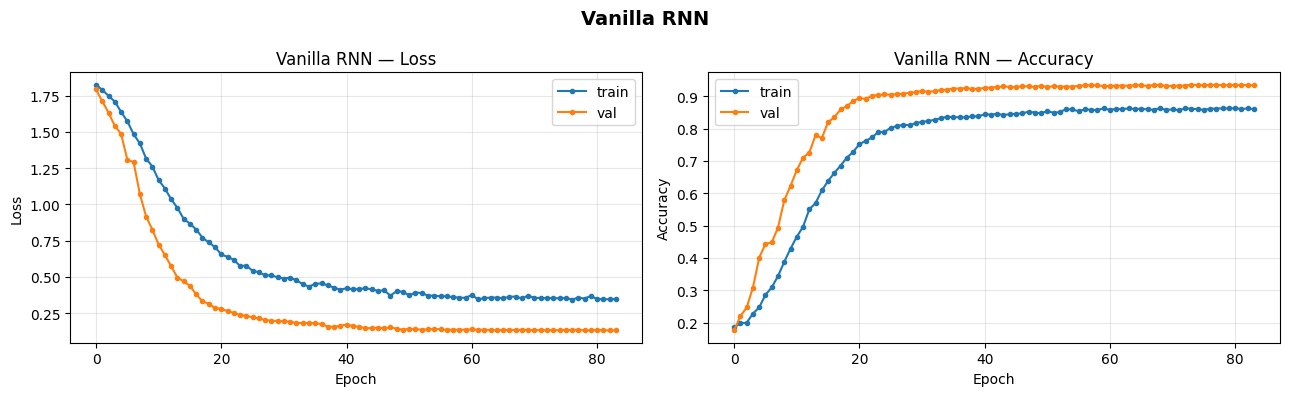

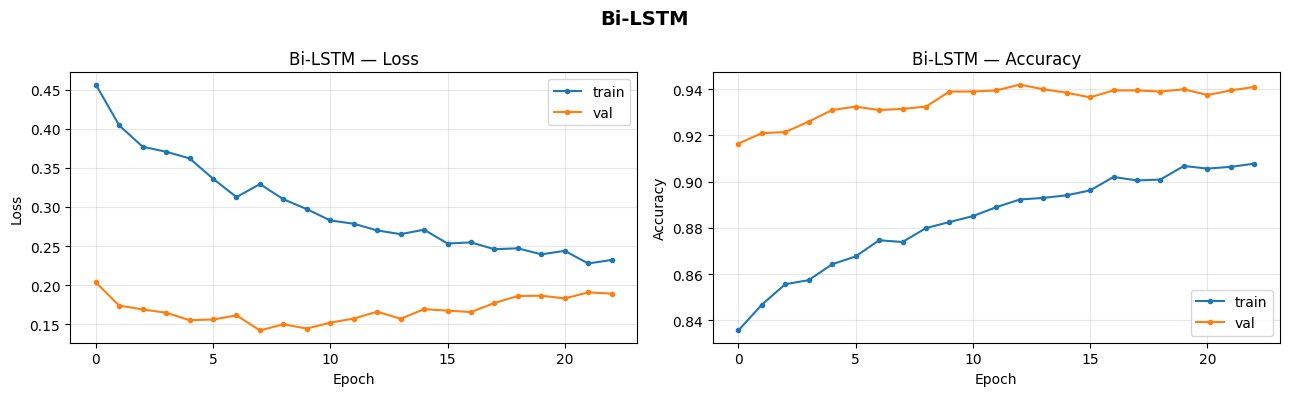

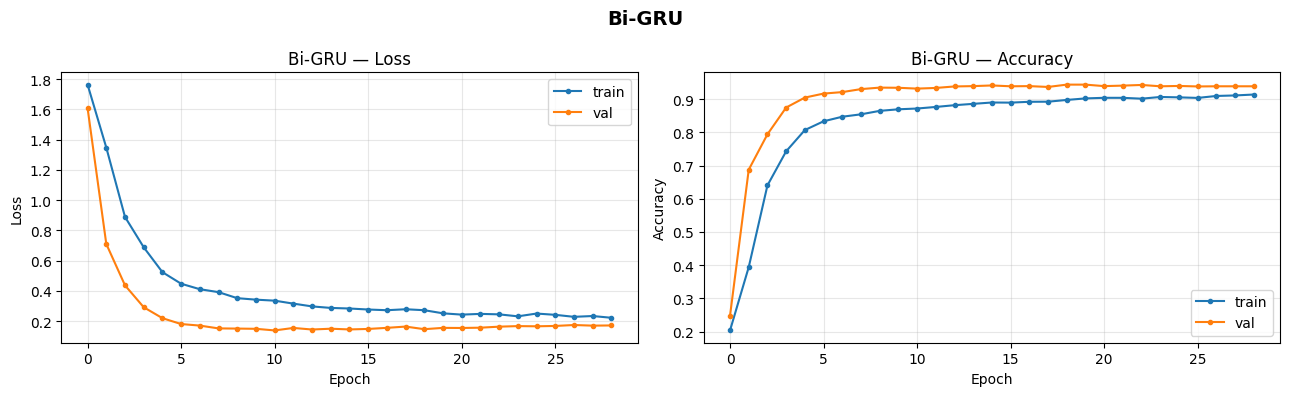

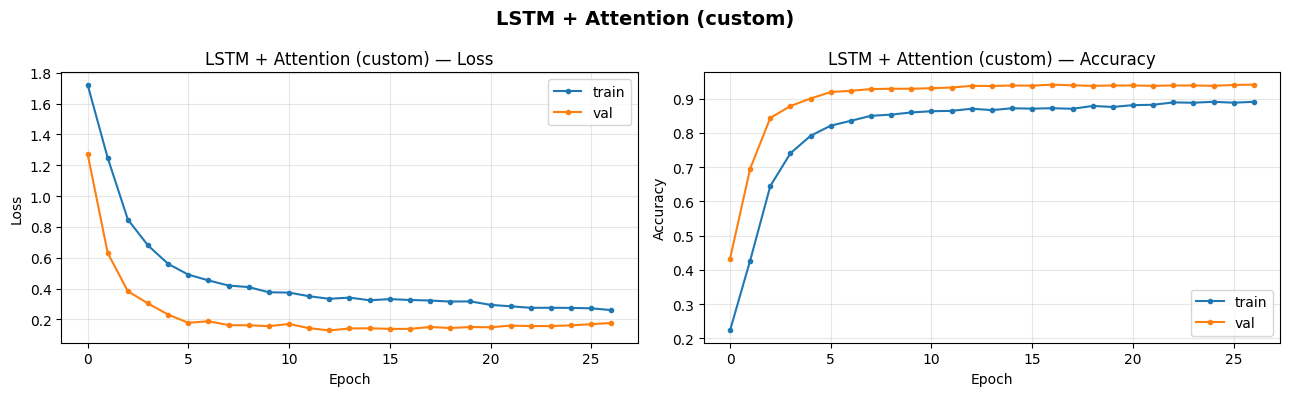

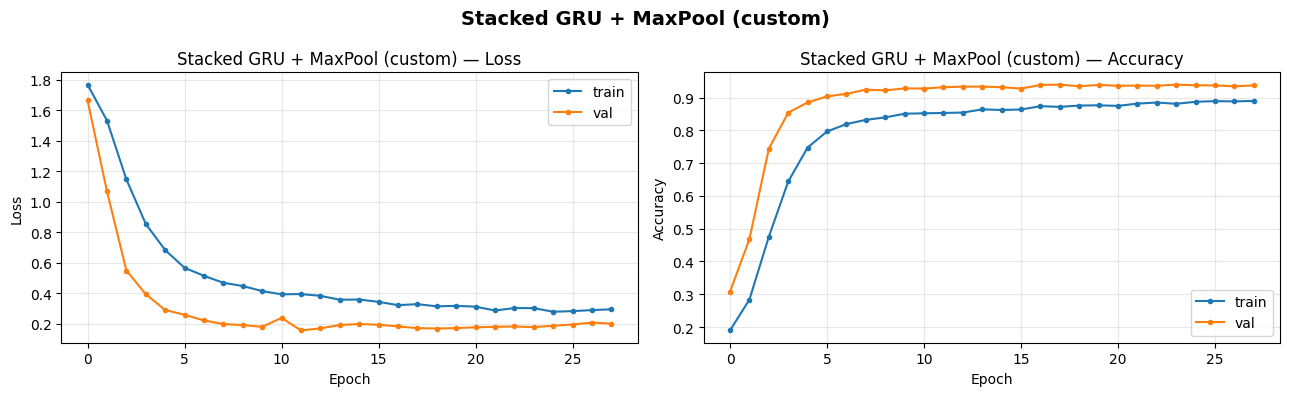

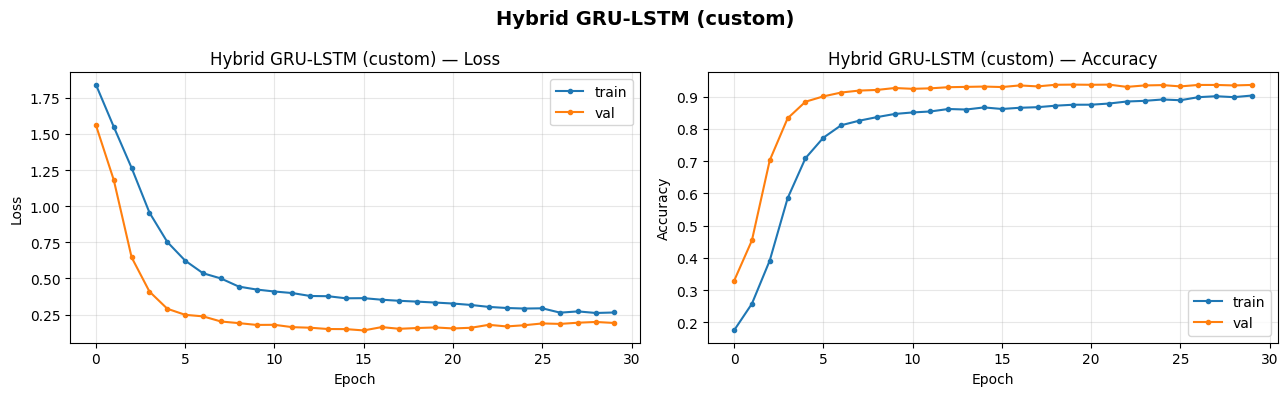

In [35]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(history["train_loss"], label="train", marker='o', markersize=3)
    axes[0].plot(history["val_loss"],   label="val",   marker='o', markersize=3)
    axes[0].set_title(f"{title} — Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(history["train_acc"], label="train", marker='o', markersize=3)
    axes[1].plot(history["val_acc"],   label="val",   marker='o', markersize=3)
    axes[1].set_title(f"{title} — Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


plot_history(history_rnn,  "Vanilla RNN")
plot_history(history_lstm, "Bi-LSTM")
plot_history(history_gru,  "Bi-GRU")
plot_history(history_v1,   "LSTM + Attention (custom)")
plot_history(history_v2,   "Stacked GRU + MaxPool (custom)")
plot_history(history_v3,   "Hybrid GRU-LSTM (custom)")


Vanilla RNN  |  Test Accuracy: 0.9260
              precision    recall  f1-score   support

     sadness       0.99      0.94      0.97       581
         joy       0.99      0.90      0.94       695
        love       0.73      0.99      0.84       159
       anger       0.90      0.97      0.93       275
        fear       0.92      0.84      0.88       224
    surprise       0.67      0.97      0.79        66

    accuracy                           0.93      2000
   macro avg       0.87      0.94      0.89      2000
weighted avg       0.94      0.93      0.93      2000



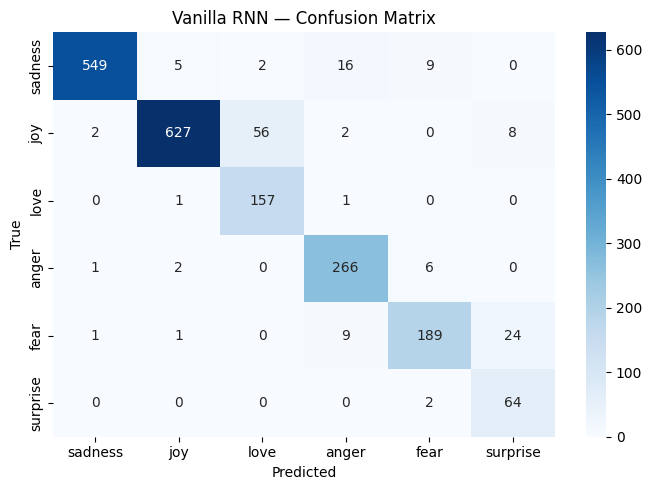


Bi-LSTM  |  Test Accuracy: 0.9300
              precision    recall  f1-score   support

     sadness       0.99      0.96      0.97       581
         joy       0.99      0.91      0.95       695
        love       0.74      0.99      0.84       159
       anger       0.94      0.95      0.94       275
        fear       0.91      0.88      0.89       224
    surprise       0.66      0.89      0.76        66

    accuracy                           0.93      2000
   macro avg       0.87      0.93      0.89      2000
weighted avg       0.94      0.93      0.93      2000



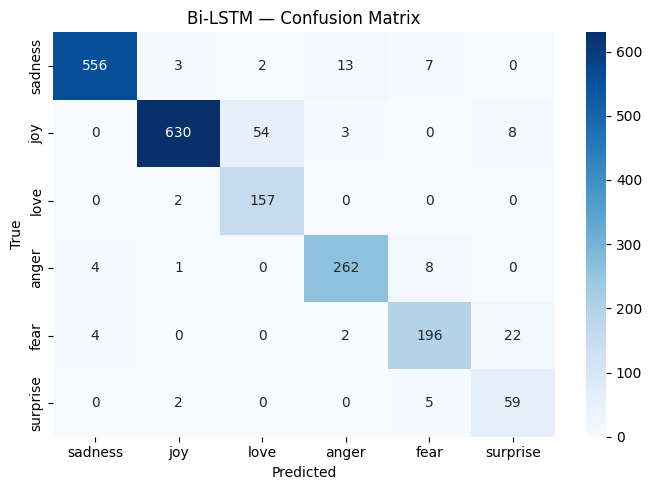


Bi-GRU  |  Test Accuracy: 0.9310
              precision    recall  f1-score   support

     sadness       0.98      0.96      0.97       581
         joy       0.97      0.92      0.95       695
        love       0.76      0.92      0.83       159
       anger       0.93      0.94      0.94       275
        fear       0.91      0.88      0.90       224
    surprise       0.70      0.94      0.81        66

    accuracy                           0.93      2000
   macro avg       0.88      0.93      0.90      2000
weighted avg       0.94      0.93      0.93      2000



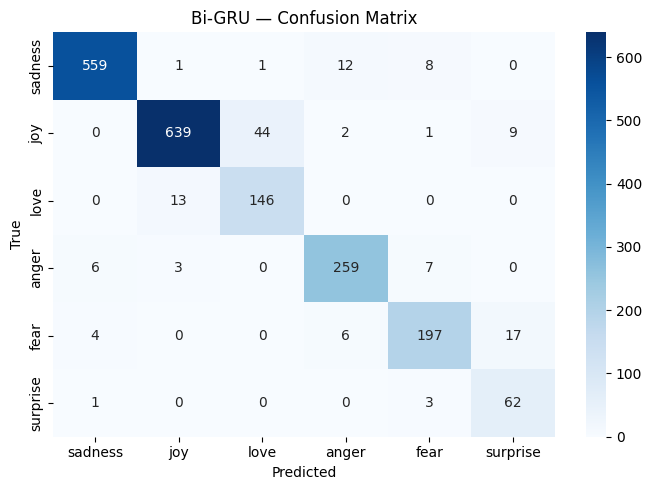


LSTM + Attention  |  Test Accuracy: 0.9285
              precision    recall  f1-score   support

     sadness       0.99      0.94      0.97       581
         joy       0.99      0.91      0.95       695
        love       0.73      0.99      0.84       159
       anger       0.91      0.96      0.93       275
        fear       0.90      0.87      0.88       224
    surprise       0.69      0.97      0.81        66

    accuracy                           0.93      2000
   macro avg       0.87      0.94      0.90      2000
weighted avg       0.94      0.93      0.93      2000



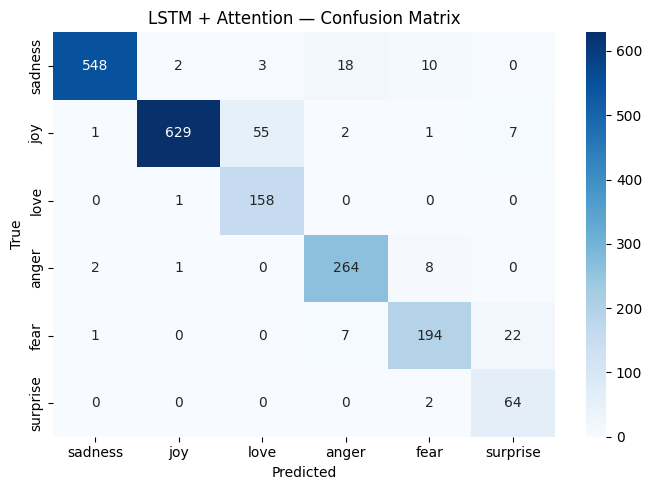


Stacked GRU + MaxPool  |  Test Accuracy: 0.9245
              precision    recall  f1-score   support

     sadness       0.98      0.95      0.97       581
         joy       0.98      0.91      0.94       695
        love       0.74      0.97      0.84       159
       anger       0.91      0.95      0.93       275
        fear       0.92      0.84      0.88       224
    surprise       0.66      0.91      0.76        66

    accuracy                           0.92      2000
   macro avg       0.86      0.92      0.89      2000
weighted avg       0.93      0.92      0.93      2000



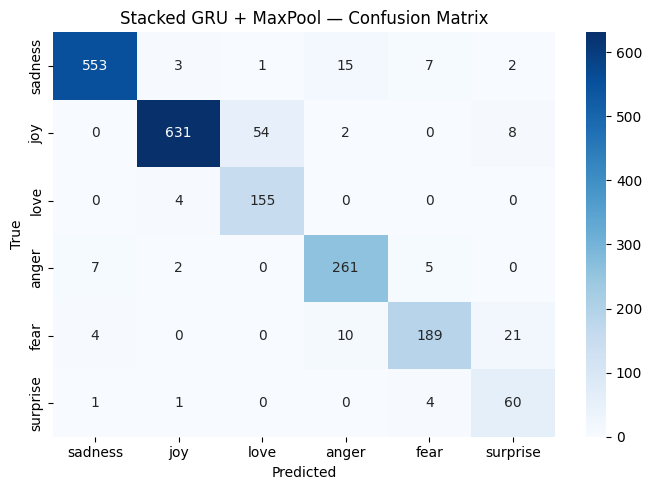


Hybrid GRU-LSTM  |  Test Accuracy: 0.9280
              precision    recall  f1-score   support

     sadness       0.99      0.95      0.97       581
         joy       0.96      0.93      0.95       695
        love       0.77      0.90      0.83       159
       anger       0.93      0.95      0.94       275
        fear       0.88      0.87      0.88       224
    surprise       0.69      0.92      0.79        66

    accuracy                           0.93      2000
   macro avg       0.87      0.92      0.89      2000
weighted avg       0.93      0.93      0.93      2000



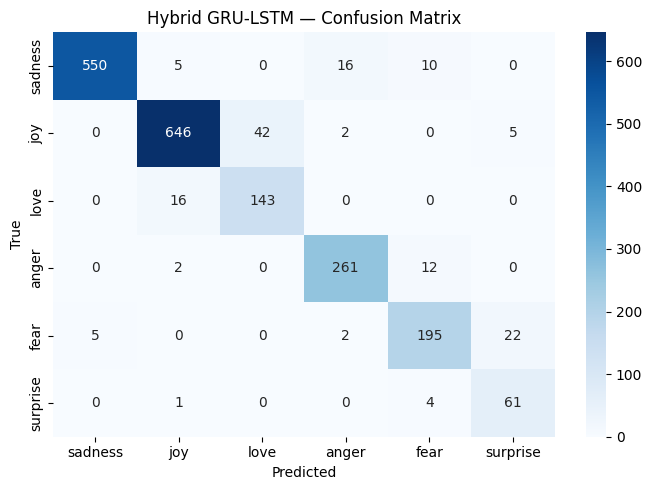

In [36]:
def evaluate_on_test(model, model_name="Model"):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            preds = model(x).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    print(f"\n{'='*50}")
    print(f"{model_name}  |  Test Accuracy: {acc:.4f}")
    print(f"{'='*50}")
    print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f"{model_name} — Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    return acc


acc_rnn  = evaluate_on_test(model_rnn,  "Vanilla RNN")
acc_lstm = evaluate_on_test(model_lstm, "Bi-LSTM")
acc_gru  = evaluate_on_test(model_gru,  "Bi-GRU")
acc_v1   = evaluate_on_test(model_v1,   "LSTM + Attention")
acc_v2   = evaluate_on_test(model_v2,   "Stacked GRU + MaxPool")
acc_v3   = evaluate_on_test(model_v3,   "Hybrid GRU-LSTM")

---
## Сравнение всех архитектур

In [37]:
results = pd.DataFrame({
    "Модель": [
        "Vanilla RNN (классическая)",
        "Bi-LSTM (классическая)",
        "Bi-GRU (классическая)",
        "LSTM + Attention (custom)",
        "Stacked GRU + MaxPool (custom)",
        "Hybrid GRU-LSTM (custom)",
    ],
    "Test Accuracy": [acc_rnn, acc_lstm, acc_gru, acc_v1, acc_v2, acc_v3],
    "Лучший Val Acc": [
        max(history_rnn["val_acc"]),
        max(history_lstm["val_acc"]),
        max(history_gru["val_acc"]),
        max(history_v1["val_acc"]),
        max(history_v2["val_acc"]),
        max(history_v3["val_acc"]),
    ],
    "Параметры": [
        sum(p.numel() for p in model_rnn.parameters()),
        sum(p.numel() for p in model_lstm.parameters()),
        sum(p.numel() for p in model_gru.parameters()),
        sum(p.numel() for p in model_v1.parameters()),
        sum(p.numel() for p in model_v2.parameters()),
        sum(p.numel() for p in model_v3.parameters()),
    ]
})

results = results.sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
results["Test Accuracy"] = results["Test Accuracy"].map("{:.4f}".format)
results["Лучший Val Acc"] = results["Лучший Val Acc"].map("{:.4f}".format)
results["Параметры"] = results["Параметры"].map("{:,}".format)
results

,Модель,Test Accuracy,Лучший Val Acc,Параметры
0,Bi-GRU (классическая),0.9310,0.9435,"2,725,894"
1,Bi-LSTM (классическая),0.9300,0.9420,"3,317,766"
2,LSTM + Attention (custom),0.9285,0.9405,"3,448,071"
3,Hybrid GRU-LSTM (custom),0.9280,0.9370,"1,674,502"
4,Vanilla RNN (классическая),0.9260,0.9360,"1,672,966"
5,Stacked GRU + MaxPool (custom),0.9245,0.9395,"2,165,702"


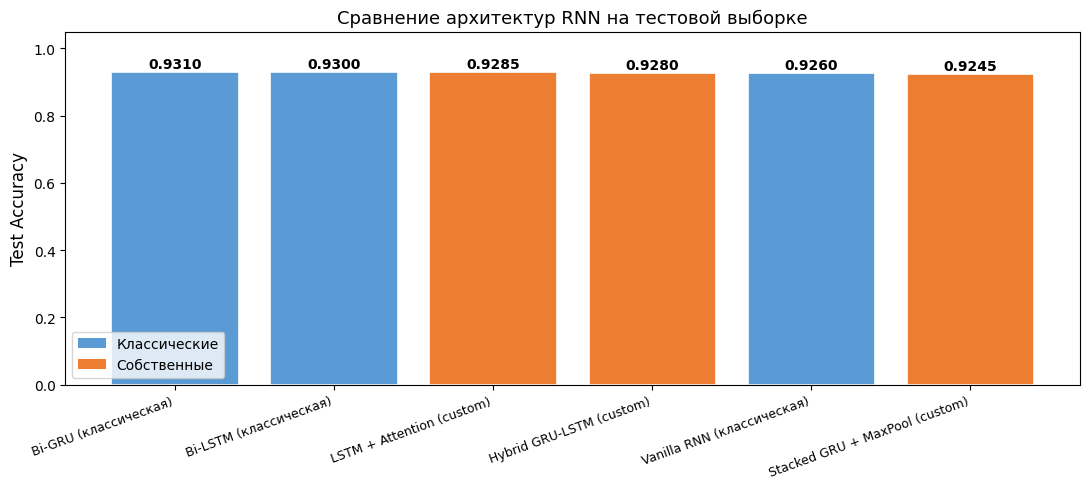

In [38]:
# Сравнительный bar-chart
model_names = results["Модель"].tolist()
accs = [float(a) for a in results["Test Accuracy"].tolist()]

colors = ["#5B9BD5" if "классическая" in n else "#ED7D31" for n in model_names]

plt.figure(figsize=(11, 5))
bars = plt.bar(model_names, accs, color=colors, edgecolor='white', linewidth=1.2)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
             f"{acc:.4f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.ylim(0, 1.05)
plt.ylabel("Test Accuracy", fontsize=12)
plt.title("Сравнение архитектур RNN на тестовой выборке", fontsize=13)
plt.xticks(rotation=20, ha='right', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#5B9BD5', label='Классические'),
                   Patch(facecolor='#ED7D31', label='Собственные')]
plt.legend(handles=legend_elements, fontsize=10)
plt.tight_layout()
plt.show()

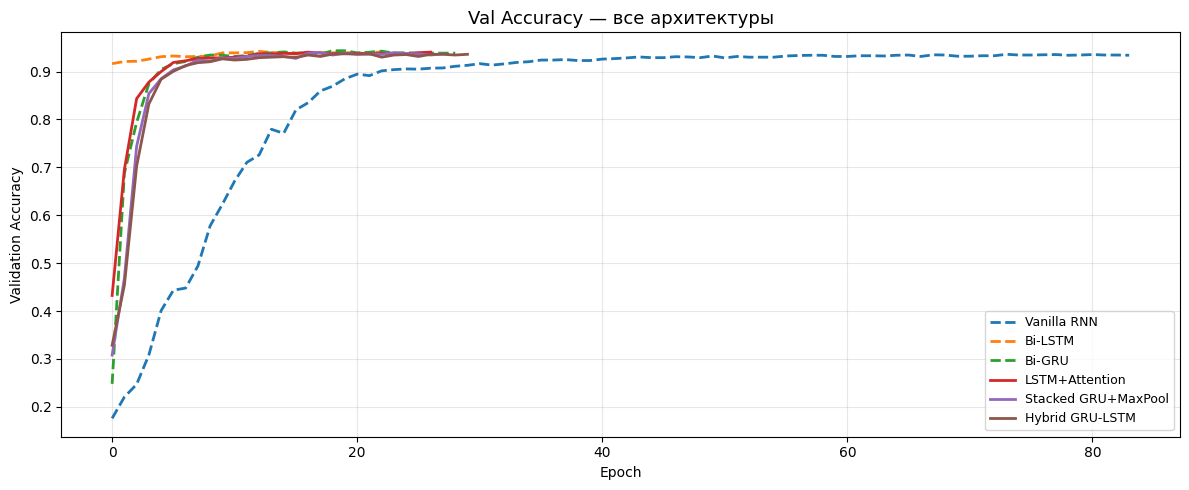

In [39]:
# Сравнение кривых обучения (val accuracy всех моделей)
plt.figure(figsize=(12, 5))
for hist, name, ls in [
    (history_rnn,  "Vanilla RNN",            "--"),
    (history_lstm, "Bi-LSTM",                "--"),
    (history_gru,  "Bi-GRU",                 "--"),
    (history_v1,   "LSTM+Attention",          "-"),
    (history_v2,   "Stacked GRU+MaxPool",     "-"),
    (history_v3,   "Hybrid GRU-LSTM",         "-"),
]:
    plt.plot(hist["val_acc"], linestyle=ls, label=name, linewidth=2)

plt.title("Val Accuracy — все архитектуры", fontsize=13)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()